# Ayudantía 3. Naive Bayes

En esta ayudantía vamos a aplicar modelos de **Naive Bayes** sobre un conjunto de datos llamado **Spambase**, disponible en el UCI Machine Learning Repository:  
<https://archive.ics.uci.edu/dataset/94/spambase>.

En este dataset, cada fila representa un correo electrónico y las columnas describen distintas características extraídas del texto, tales como:

* Frecuencia relativa de ciertas palabras y símbolos (por ejemplo, `free`, `money`, `!`).
* Porcentaje de letras en mayúscula.
* Medidas relacionadas con la longitud y variabilidad de las secuencias en mayúscula.

La variable objetivo indica si el correo fue clasificado como **spam** o **no spam**.

Este tipo de modelo se utiliza para:

* Filtrar automáticamente correos no deseados antes de que lleguen al usuario.
* Reducir riesgos de seguridad asociados a phishing y campañas maliciosas.
* Optimizar el tiempo de los equipos comerciales y de soporte, evitando que su bandeja de entrada se llene de mensajes irrelevantes.

En esta ayudantía:

* Con **Naive Bayes** construiremos un clasificador probabilístico.


# Librerías




In [1]:
# Librerías estándar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# dataset
from ucimlrepo import fetch_ucirepo 

# herramientas de sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_fscore_support
from sklearn.metrics import matthews_corrcoef

# reducción de dimensionalidad
from sklearn.decomposition import PCA

# Configuración opcional de gráficos
plt.style.use("default") 
sns.set(style="whitegrid", context="notebook") # fondo blanco y cuadrícula ligera

# Configuración warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# Cargar dataset

In [2]:
# Descargamos el dataset Spambase (ID 94) directo de UCI ML Repository
dataset = fetch_ucirepo(id=94)

# Acceder a los datos de características y etiquetas
caracteristicas = dataset.data.features
etiquetas  = dataset.data.targets

data = pd.concat([caracteristicas, etiquetas], axis=1)


## Información del dataset

In [3]:
data.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [4]:
print("Dimensiones del dataset:", data.shape)
print("\nTipos de datos:")
print(data.info())


Dimensiones del dataset: (4601, 58)

Tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-

El conjunto de datos Spambase no presenta valores faltantes en ninguna de sus variables, incluyendo la variable objetivo ``Class``. Contiene 4601 correos electrónicos y 58 columnas.

* En el dataset se encuentran los siguientes tipos de datos:

    * 55 variables numéricas continuas (float64) que miden frecuencias relativas de palabras y caracteres.

    * 2 variables numéricas discretas (int64): capital_run_length_longest y capital_run_length_total.

    * 1 variable objetivo (Class, también entera) que indica si el correo es spam.

* La variable objetivo Class toma dos valores:

    - 1: el correo fue marcado como spam.

    - 0: el correo fue marcado como no spam.

* Las variables que comienzan con word_freq_ (word_freq_free, word_freq_money, word_freq_you) representan el porcentaje de palabras del correo que corresponden a ese término específico. Valores más altos indican que ese término aparece con mayor frecuencia en el mensaje.

* Las variables char_freq_;, char_freq_(, char_freq_[, char_freq_!, char_freq_$ y char_freq_# corresponden al porcentaje de caracteres del correo que son esos símbolos particulares. Muchos filtros de spam se apoyan en estos patrones porque ciertos símbolos son típicos en correos promocionales o maliciosos.

* Las variables capital_run_length_average, capital_run_length_longest y capital_run_length_total resumen el uso de secuencias de letras en mayúscula dentro del correo. Estas métricas ayudan a detectar correos que intentan llamar la atención mediante mayúsculas excesivas, algo habitual en mensajes de spam.

### Duplicados

In [5]:
print(f"\nDuplicados: {data.duplicated().sum()}")


Duplicados: 391


In [6]:
# Eliminar filas duplicadas y reiniciar el índice
data = data.drop_duplicates().reset_index(drop=True)

# Verificar que ya no queden duplicados
print(f"\nDuplicados: {data.duplicated().sum()}")


Duplicados: 0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4210 entries, 0 to 4209
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4210 non-null   float64
 1   word_freq_address           4210 non-null   float64
 2   word_freq_all               4210 non-null   float64
 3   word_freq_3d                4210 non-null   float64
 4   word_freq_our               4210 non-null   float64
 5   word_freq_over              4210 non-null   float64
 6   word_freq_remove            4210 non-null   float64
 7   word_freq_internet          4210 non-null   float64
 8   word_freq_order             4210 non-null   float64
 9   word_freq_mail              4210 non-null   float64
 10  word_freq_receive           4210 non-null   float64
 11  word_freq_will              4210 non-null   float64
 12  word_freq_people            4210 non-null   float64
 13  word_freq_report            4210 

# Análisis Exploratorio de los datos

In [8]:
data.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
count,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,...,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000
mean,0.104366,0.112656,0.291473,0.063078,0.325321,0.096656,0.117475,0.108000,0.091860,0.248420,...,0.040403,0.144048,0.017376,0.281136,0.076057,0.045798,5.383896,52.139905,291.181948,0.398812
std,0.300005,0.454260,0.515719,1.352487,0.687805,0.276030,0.397284,0.410282,0.282144,0.656638,...,0.252533,0.274256,0.105731,0.843321,0.239708,0.435925,33.147358,199.582168,618.654838,0.489712
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.627500,7.000000,40.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.073000,0.000000,0.016000,0.000000,0.000000,2.297000,15.000000,101.500000,0.000000
75%,0.000000,0.000000,0.440000,0.000000,0.410000,0.000000,0.000000,0.000000,0.000000,0.190000,...,0.000000,0.194000,0.000000,0.331000,0.053000,0.000000,3.706750,44.000000,273.750000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


## Distribución de la variable objetivo

Class
0    2531
1    1679
Name: count, dtype: int64 Class
0    0.601188
1    0.398812
Name: proportion, dtype: float64


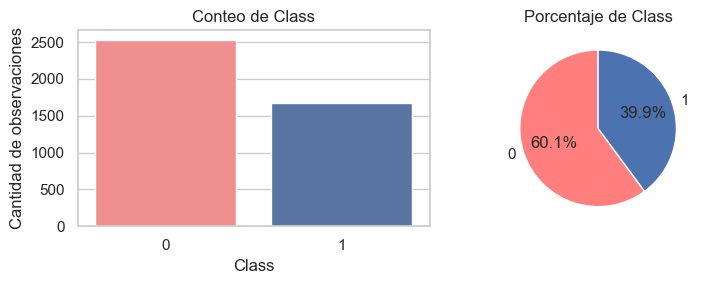

In [9]:
print(data['Class'].value_counts(), data['Class'].value_counts(normalize=True))
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Gráfico de barras (conteo)
sns.countplot(x="Class", data=data, ax=axes[0], palette=["#FF7F7F","#4C72B0"])
axes[0].set_title("Conteo de Class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Cantidad de observaciones")

# Gráfico de pastel (porcentaje)
Class_counts = data["Class"].value_counts()
Class_labels = Class_counts.index
axes[1].pie(Class_counts, labels=Class_labels, autopct='%1.1f%%', startangle=90, colors=["#FF7F7F","#4C72B0"])
axes[1].set_title("Porcentaje de Class")

plt.tight_layout()
plt.show()


El desbalanceo de clases en una proporción aproximada de 60 % a 40 % es generalmente aceptable para los modelos de clasificación, ya que permite que tanto la clase mayoritaria como la minoritaria tengan suficiente representatividad en el entrenamiento y la evaluación. El desbalanceo se vuelve problemático y riesgoso para la estabilidad del modelo cuando la proporción es mucho más extrema, por ejemplo 90 % a 10 %, ya que el modelo tiende a favorecer la clase mayoritaria y puede tener dificultades para identificar correctamente la minoritaria, afectando métricas como recall, F1 y la utilidad práctica en casos críticos.

## Distribución de las variables numéricas

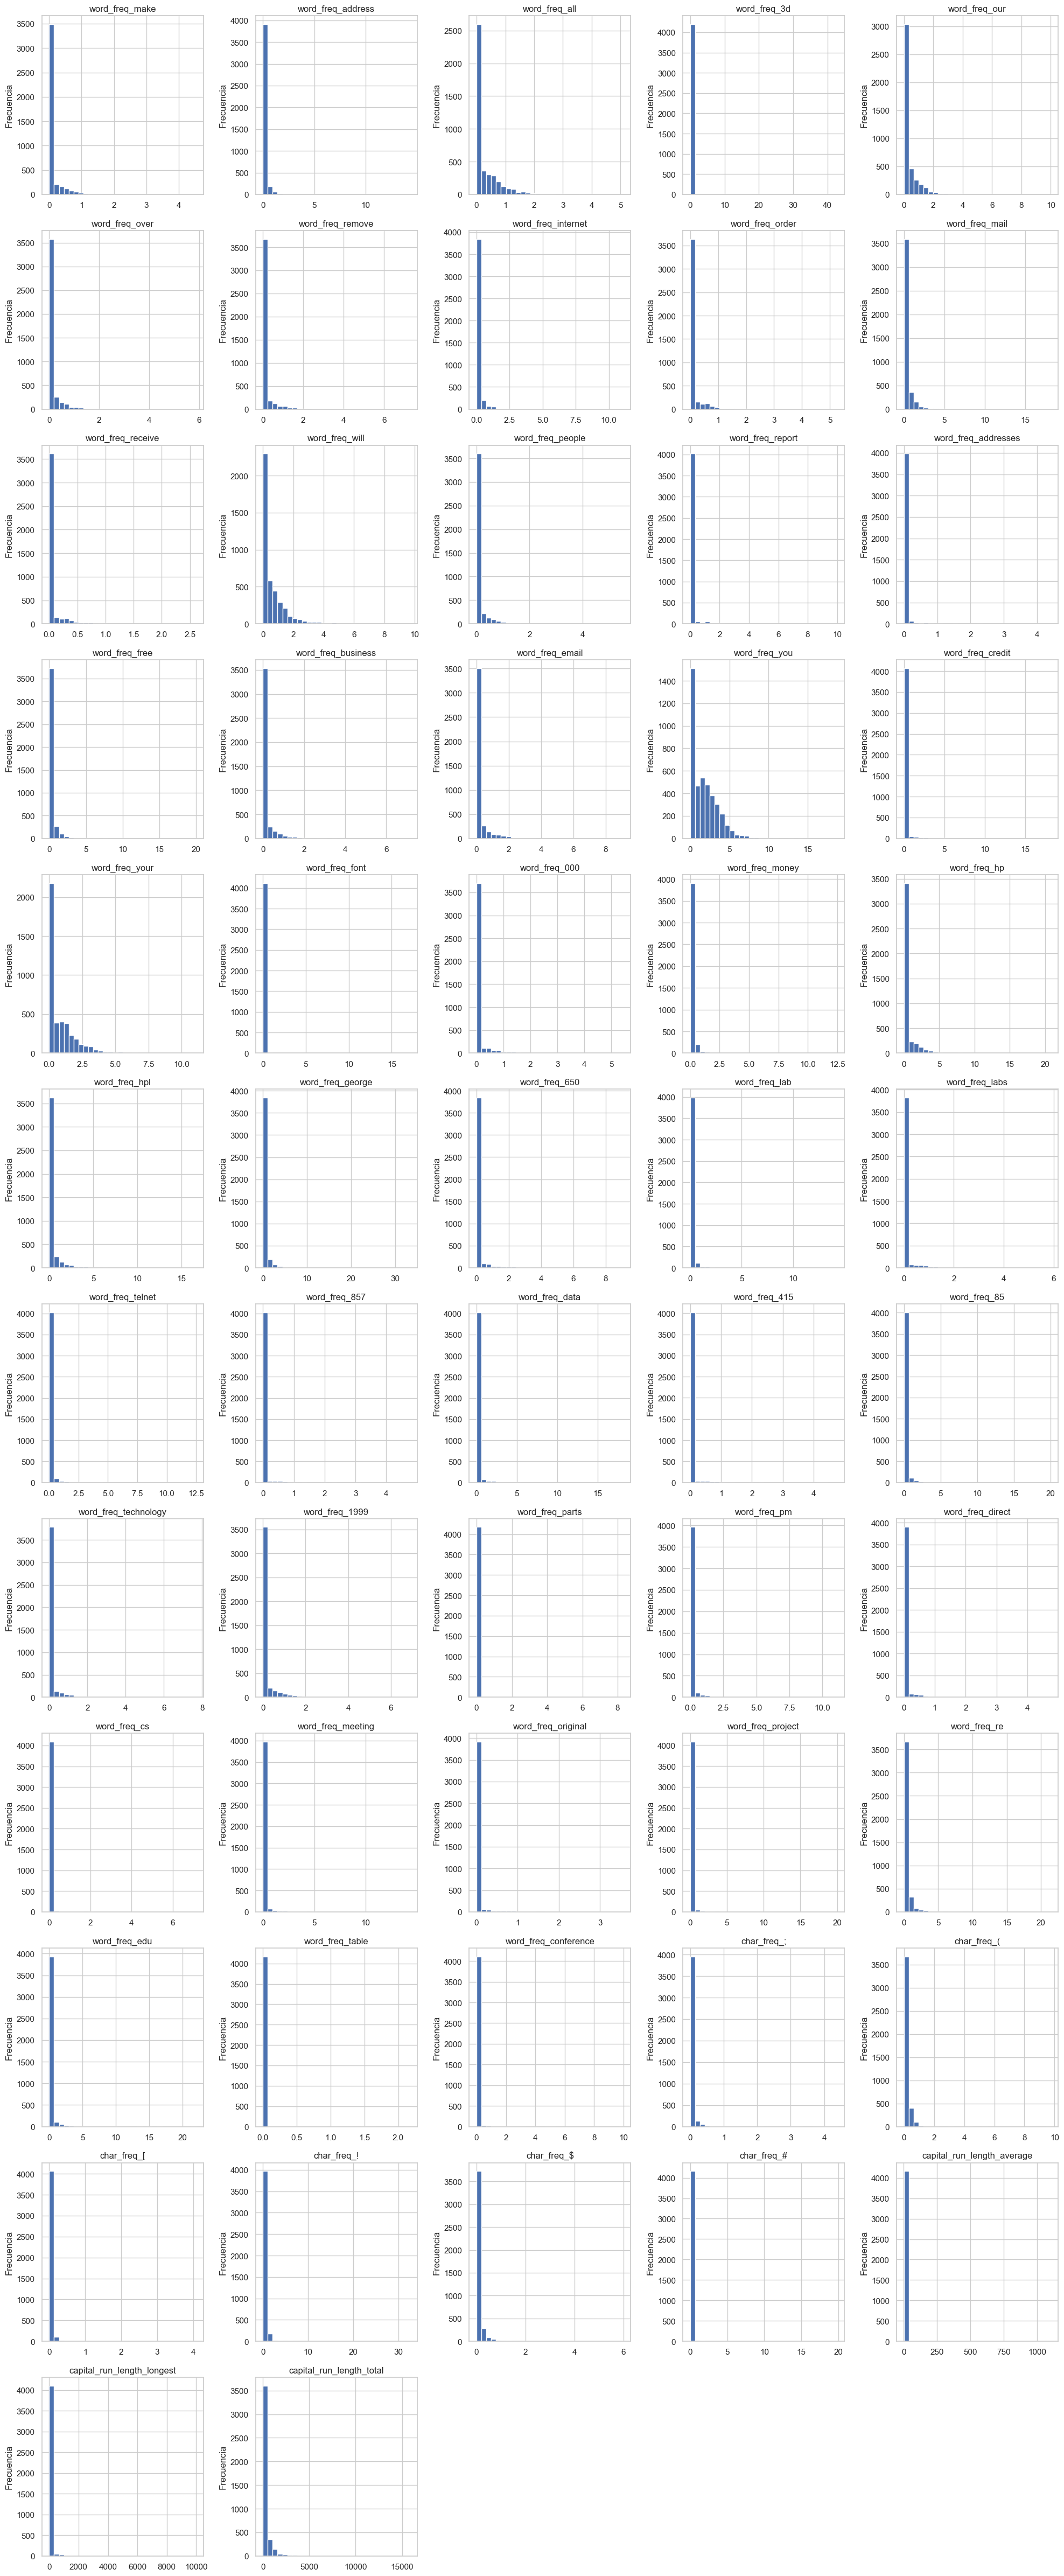

In [10]:
# Seleccionar todas las columnas numéricas excepto la variable objetivo
numeric_cols = data.columns.drop('Class')

len(numeric_cols), numeric_cols[:5]

# Histogramas

n_cols = 5   # número de gráficos por fila
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    axes[i].hist(data[col], bins=30)
    axes[i].set_title(col)
    axes[i].set_ylabel('Frecuencia')

# Apagar ejes sobrantes si sobran casillas
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


* La mayoría de las variables de frecuencia de palabras y caracteres presentan distribuciones muy sesgadas con colas largas: el valor más frecuente es 0, mientras que una pequeña proporción de datos muestra frecuencias altas. Esto se refleja en los histogramas y estadísticas, con medianas y percentiles bajos, pero máximos elevados.

* Las variables relacionadas con longitudes de mayúsculas muestran gran dispersión, con valores máximos extremos y desviaciones estándar altas, evidenciando la presencia de outliers.

* El sesgo hacia 0 indica que la mayoría de los correos no contienen ciertas palabras o símbolos, pero los pocos que sí las tienen son informativos para la clasificación, especialmente en spam.

* No es necesario un tratamiento específico de outliers, ya que los valores extremos aportan información útil para el modelo. Las colas largas en las frecuencias corresponden a correos con palabras o caracteres repetidos, característicos de mensajes spam, por lo que son señal más que ruido.

* Desde el punto de vista de Naive Bayes gaussiano, aunque valores extremos pueden inflar varianzas, aquí las variables son frecuencias acotadas y el dataset es lo suficientemente grande, además de contar con estandarización que reduce el efecto de estas colas.

* Para un preprocesamiento más fino, se podría aplicar transformaciones logarítmicas o usar un RobustScaler en lugar del StandardScaler en variables muy asimétricas, así se mitiga la sensibilidad del modelo a valores extremos sin eliminar observaciones relevantes del patrón spam.

# División del dataset

In [11]:
# Matriz de características y variable objetivo
X = data[numeric_cols]
y = data['Class']

# División en entrenamiento y prueba, estratificando por la clase
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X.shape, y.shape)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(4210, 57) (4210,)
(3368, 57) (842, 57) (3368,) (842,)


* **Observación**: En este caso no es necesario codificar, todas las columnas son numéricas (son float64) y la variable objetivo Class ya viene como ``no spam: 0``  y  ``spam: 1``.

## Transformación logarítmica

Transformación logarítmica en las variables numéricas de X y ya que todas las columnas de X son no negativas, log1p es seguro de aplicar.

In [12]:
X_train_log = X_train.copy()
X_test_log  = X_test.copy()

X_train_log = np.log1p(X_train_log)
X_test_log  = np.log1p(X_test_log)

### Escalar las variables numéricas

Después de aplicar la transformación logarítmica a las variables de frecuencia, estandarizamos las características usando `RobustScaler`. A diferencia de `StandardScaler`, que utiliza la media y la desviación estándar, `RobustScaler` centra los datos en la mediana y los escala según el rango intercuartílico (IQR). 

Esta elección es coherente con la estructura del dataset: muchas variables `word_freq_*`, `char_freq_*` y las longitudes de mayúsculas presentan colas largas y valores extremos que contienen información relevante sobre el patrón de spam. Con `RobustScaler` no eliminamos esos valores, pero evitamos que dominen las estadísticas del modelo. De este modo, Naive Bayes trabaja sobre variables con una escala más homogénea, manteniendo la señal de los correos muy “intensos” sin que unos pocos casos empujen en exceso la estimación de las varianzas.

In [13]:
# Escalamos todas las variables numéricas
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled  = scaler.transform(X_test_log)

print(X_train_scaled.shape, X_test_scaled.shape)


(3368, 57) (842, 57)


# Algoritmo Naive Bayes
<div style="text-align: center;">
    <img src="naive_bayes.jpg" alt="Descripción de la imagen" width="800">
    <p>Imagen tomada de: <a href="https://medium.com/@patwariraghottam/mastering-naive-bayes-a-comprehensive-python-guide-to-probabilistic-classification-b7fe67c6763f" target="_blank">https://medium.com/@patwariraghottam/mastering-naive-bayes-a-comprehensive-python-guide-to-probabilistic-classification-b7fe67c6763f</a></p>
</div>

El algoritmo «Naive Bayes» es un clasificador probabilístico (las predicciones se basan en calcular probabilidades) basado en el «Teorema de Bayes», el modelo fue creado por el matemático inglés, Thomas Bayes (1701 – 1761), para tratar de probar la existencia de Dios.

El término “naive” (ingenuo en español) se refiere a la forma en que el algoritmo analiza las características de una base de datos: ignora la correlación entre las variables características, es decir, asume que el efecto de una variable es independiente al resto de variables. Por ejemplo, si una pelota está etiquetada como «Pelota de tenis», y si también se describe como «Amarillo fluorescente» y «Diámetro pequeño», el algoritmo no tendrá en cuenta la correlación entre estos factores. 

* Características principales:
    - La idea principal detrás del clasificador Naive Bayes es utilizar Teorema de Bayes clasificar datos en función de las probabilidades de diferentes clases dadas las características de los datos. 
    - Se utiliza principalmente en la clasificación de textos de alta dimensión
    - El clasificador Naive Bayes es un clasificador probabilístico simple y tiene muy pocos parámetros que se utilizan para construir modelos ML que puedan predecir a una velocidad más rápida que otros algoritmos de clasificación.
    - Es un clasificador probabilístico porque supone que una característica del modelo es independiente de la existencia de otra característica. En otras palabras, cada característica contribuye a las predicciones sin relación entre sí.
    - El algoritmo Naive Bayes se utiliza en la filtración de spam, el análisis sentimental, la clasificación de artículos y muchos más.

Existen variantes de Naive Bayes que se adaptan a distintos tipos de datos:

* **MultinomialNB**: Se utiliza cuando las características representan conteos o frecuencias discretas, como el número de veces que aparece una palabra en un texto o sus frecuencias relativas (por ejemplo, matrices de conteos o TF-IDF). Es habitual en tareas de clasificación de texto.

* **BernoulliNB**: Resulta adecuado cuando las características son binarias (0/1), indicando presencia o ausencia de un atributo, por ejemplo si una palabra aparece o no en un documento tras binarizar la matriz de términos.

* **GaussianNB**: Supone que las variables numéricas siguen una distribución normal dentro de cada clase, y modela cada predictor como una variable continua. Es apropiado para datos numéricos continuos, como duraciones, mediciones o características derivadas que se tratan como variables reales.

En este ejercicio utilizaremos el modelo Naive Bayes gaussiano, ya que todas las variables explicativas del conjunto de datos son numéricas y, tras el escalado, se ajustan razonablemente al supuesto de variables continuas condicionadas a la clase.

En scikit-learn, el modelo se implementa con la clase GaussianNB:

```python
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB(var_smoothing=1e-9, priors=None) # valores por defecto
```
| Hiperparámetro    | Descripción                                                                                                                                                                                     |
| ----------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **var_smoothing** | Término de suavizado que se suma a la varianza de cada característica. Evita problemas numéricos cuando la varianza estimada es muy pequeña. Valores típicos van desde `1e-9` hacia arriba.     |
| **priors**        | Permite fijar manualmente las probabilidades a priori de cada clase. Si se deja en `None`, el modelo estima las priors a partir de las frecuencias de las clases en los datos de entrenamiento. |

* Recomendaciones:
    - Para muchos problemas de clasificación, el valor por defecto var_smoothing=1e-9 funciona razonablemente bien. En casos con muchas variables o fuerte desbalance, se puede ajustar por validación cruzada.
    - Mantener priors=None cuando no se tiene información previa sobre la distribución de las clases y se quiere que el modelo use las proporciones observadas en los datos de entrenamiento.
    - Recordar que GaussianNB asume que, condicionadas a la clase, las variables numéricas siguen una distribución normal y son condicionalmente independientes entre sí.

* Métodos principales del modelo:
    - **nb_model.fit(X_train, y_train)**: ajusta el modelo a los datos de entrenamiento.
    - **nb_model.predict(X_test)**: entrega la clase predicha para cada observación en el conjunto de prueba.
    - **nb_model.predict_proba(X_test)**: entrega las probabilidades estimadas para cada clase.

## Definimos y ajustamos el modelo

In [14]:
# Definir el modelo con hiperparámetros por defecto
nb_model = GaussianNB()

# Entrenar con los datos ya escalados
nb_model.fit(X_train_scaled, y_train)

,priors,None
,var_smoothing,1e-09


Aunque GaussianNB tiene pocos hiperparámetros, es posible buscar la mejor configuración usando validación cruzada. Por ejemplo, se puede ajustar el parámetro 'var_smoothing' que agrega un valor para estabilidad numérica usando ``GridSearchCV`` de la siguiente manera:

```python
from sklearn.model_selection import GridSearchCV

param_grid = {'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06, 1e-05]}
grid_search = GridSearchCV(GaussianNB(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor precisión CV:", grid_search.best_score_)

# El modelo optimizado se puede usar así:
best_nb_model = grid_search.best_estimator_
```

Pueden cambiar la métrica en ``scoring = 'accuracy'`` por f1-score, recall métricas específicas de la clase positiva, según el objetivo del problema.

Por otra parte, en la mayoría de los casos el parámetro ``priors`` se deja en ``None``. Cuando el conjunto de datos está muy desbalanceado y existe información previa relevante sobre la proporción de clases, fijar priors puede ayudar a incorporar ese conocimiento. Los valores del vector deben sumar 1 y su longitud debe coincidir con el número de clases. Por ejemplo, para dos clases:

```python
param_grid = {
    'var_smoothing': [1e-09, 1e-08, 1e-07],
    'priors': [None, [0.6, 0.4], [0.5, 0.5]] # Para este ejemplo sólo hay dos clases
}
```

## Predicciones y resultados

Para esta sección utilizaremos las métricas básicas de clasificación —matriz de confusión, precisión, recall, F1-score y ROC/AUC—, métricas adecuadas para contexto de clasificación con las cuales podremos evaluar razonablemente el desempeño de los modelos.

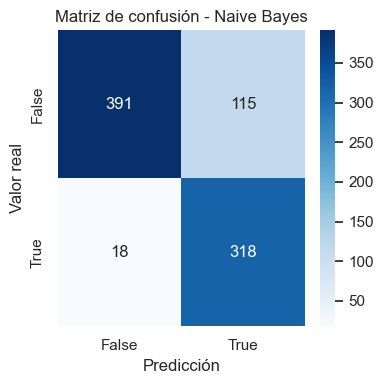


Naive Bayes - Reporte de clasificación
              precision    recall  f1-score   support

           0       0.96      0.77      0.85       506
           1       0.73      0.95      0.83       336

    accuracy                           0.84       842
   macro avg       0.85      0.86      0.84       842
weighted avg       0.87      0.84      0.84       842



In [15]:
# Predicciones en el conjunto de prueba
y_pred_nb = nb_model.predict(X_test_scaled)

# Matriz de confusión y métricas
cm = confusion_matrix(y_test, y_pred_nb)
labels = ['False', 'True']  # orden de las clases

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión - Naive Bayes')
plt.tight_layout()
plt.show()

print("\nNaive Bayes - Reporte de clasificación")
print(classification_report(y_test, y_pred_nb))

* Para este ejercicio la matriz de confusión tiene la siguiente forma:

|               | Pred: No spam | Pred: Spam |
| ------------- | ------------- | ---------- |
| Real: No spam | TN            | FP         |
| Real: Spam    | FN            | TP         |

De lo que podemos definir:
* TN (true negatives): correos legítimos (no spam) que el modelo identifica como no spam.
* FP (false positives): correos legítimos (no spam) marcados como spam. Son molestas para el usuario, pero no implican riesgo de seguridad.
* FN (false negatives): spam que el modelo deja pasar como correo normal. Aquí está el riesgo: phishing, fraudes, malware.
* TP (true positives): spam correctamente detectado.

Luego, podemos concluir que:
* El modelo acierta la mayoría de los casos: TN + TN = 391 + 318 = 709 aproximadamente el 84% de los casos.
* El **FN** es bajo (18) por lo que el modelo no deja pasar mucho los correos spam como normal
* El **FP** si es un poco alto (115) por lo que le modelo causa muchas molestias a los usuarios marcando spam como no spam.

De las métricas podemos concluir:
* Con Accuracy ≈ 0.84 se valida que el modelo acierta en torno al 84% de los correos del conjunto de prueba.
* Macro avg y weighted avg muy similares (≈ 0.83–0.85). Esto indica que el modelo trata de forma bastante equilibrada a ambas clases.
* Precision 0.96. Cuando el modelo dice “esto es no spam”, casi siempre acierta.
* Recall 0.77. De todos los correos que realmente son no spam, el modelo identifica correctamente un 77%
* F1 = 0.85. Resume ese equilibrio entre precision y recall.

Desde el punto de vista de la clase 1 (spam), tenemos que:
* Precision 0.73. De todos los correos que el modelo marca como spam, un 73% son realmente spam. El 27% restante son correos legítimos que el modelo está sobre–clasificando como spam (falsos positivos desde la perspectiva de la clase 1).
* Recall 0.95. De todos los correos que realmente son spam, el modelo detecta un 95%. Es decir, se le escapa muy poco spam.
* F1 = 0.83. Bastante sólido: refleja que el modelo consigue un buen compromiso entre “atrapar casi todo el spam” y “no pasarse bloqueando correos legítimos”.



In [16]:
# Probabilidades predichas para la clase spam (Class = 1)
y_proba_nb = nb_model.predict_proba(X_test_scaled)

# Crear DataFrame con los resultados
result_df = pd.DataFrame({
    'Observacion': range(len(y_proba_nb)),
    'P(Class=0)': y_proba_nb[:, 0],
    'P(Class=1)': y_proba_nb[:, 1],
    'Valor_real': y_test.reset_index(drop=True)
})

# Mostrar primeras 10 filas
print(result_df.head(10))


   Observacion    P(Class=0)    P(Class=1)  Valor_real
0            0  1.812541e-23  1.000000e+00           1
1            1  1.000000e+00  2.351457e-99           0
2            2  3.357315e-40  1.000000e+00           1
3            3  2.354800e-11  1.000000e+00           1
4            4  1.690493e-20  1.000000e+00           0
5            5  1.000000e+00  0.000000e+00           0
6            6  5.502701e-14  1.000000e+00           1
7            7  1.124979e-23  1.000000e+00           1
8            8  1.000000e+00  0.000000e+00           0
9            9  1.163829e-18  1.000000e+00           1


In [17]:
# Probabilidad estimada de spam
proba_spam = y_proba_nb[:, 1]

# Construir el DataFrame con las columnas deseadas
resultados_nb = pd.DataFrame({
    'Class_real': y_test.values,      # 0 = no spam, 1 = spam
    'Class_pred': y_pred_nb,          # predicción de Naive Bayes
    'Proba_spam': proba_spam          # probabilidad estimada de spam (clase 1)
})

# Algunas columnas originales para contexto adicional
cols_contexto = [
    'word_freq_free',
    'word_freq_money',
    'word_freq_you',
    'char_freq_$',
    'char_freq_!',
    'capital_run_length_total'
]

# Agregar columnas de contexto, reseteando índices para alinear
resultados_nb[cols_contexto] = X_test[cols_contexto].reset_index(drop=True)

# Mostrar primeras 10 filas
resultados_nb.head(10)


,Class_real,Class_pred,Proba_spam,word_freq_free,word_freq_money,word_freq_you,char_freq_$,char_freq_!,capital_run_length_total
0,1,1,1.000000e+00,0.00,0.59,3.57,0.000,0.103,161
1,0,0,2.351457e-99,0.00,0.00,0.00,0.000,0.000,78
2,1,1,1.000000e+00,0.46,0.00,1.86,0.168,1.683,742
3,1,1,1.000000e+00,0.00,0.00,2.46,0.000,0.415,42
4,0,1,1.000000e+00,0.00,0.00,1.25,0.000,0.045,98
5,0,0,0.000000e+00,0.00,0.00,0.00,0.000,0.000,69
6,1,1,1.000000e+00,0.00,0.00,2.79,0.000,0.057,110
7,1,1,1.000000e+00,0.32,0.32,2.28,0.166,0.000,139
8,0,0,0.000000e+00,0.00,0.00,0.00,0.000,0.000,40
9,1,1,1.000000e+00,1.28,0.00,3.84,0.230,0.230,72


## Curva ROC y AUC

AUC Naive Bayes: 0.9534484989648032


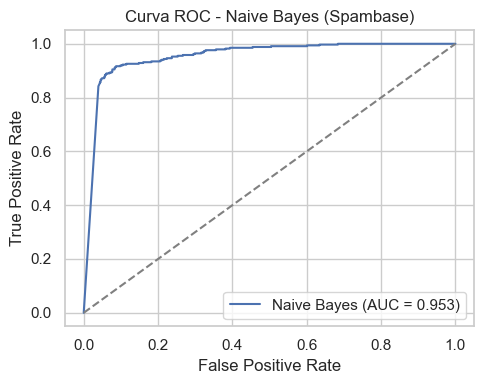

In [18]:
# Curva ROC y AUC 
fpr, tpr, thresholds = roc_curve(y_test, proba_spam)
auc_nb = roc_auc_score(y_test, proba_spam)
print("AUC Naive Bayes:", auc_nb)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'Naive Bayes (AUC = {auc_nb:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Naive Bayes (Spambase)')
plt.legend()
plt.tight_layout()
plt.show()


El valor de AUC (Área Bajo la Curva ROC) de 0.953 obtenido para el modelo Naive Bayes indica un desempeño excelente en la tarea de clasificación de correos spam, es decir, nos está indicando que el modelo distingue muy bien entre las clases positivas (spam) y negativas (no spam), logrando altas tasas de verdaderos positivos mientras mantiene bajas tasas de falsos positivos en una amplia variedad de umbrales. 

## Análisis de umbrales de decisión

In [19]:
umbrales = [0.3, 0.5, 0.7, 0.9, 0.95]
filas = []
cms = []   # para guardar las matrices de confusión junto al umbral

for thr in umbrales:
    # Predicción binaria según el umbral
    y_pred_th = (proba_spam >= thr).astype(int)
    mcc = matthews_corrcoef(y_test, y_pred_th)
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred_th)
    tn, fp, fn, tp = cm.ravel()
    cms.append((thr, cm))
    
    # Métricas para la clase spam (=1)
    acc = accuracy_score(y_test, y_pred_th)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred_th,
        pos_label=1,
        average='binary'
    )
    
    filas.append({
        'Umbral': thr,
        'Accuracy': acc,
        'Precision_spam': prec,
        'Recall_spam': rec,
        'F1_spam': f1,
        'MCC': mcc
    })

tabla_umbral = pd.DataFrame(filas)


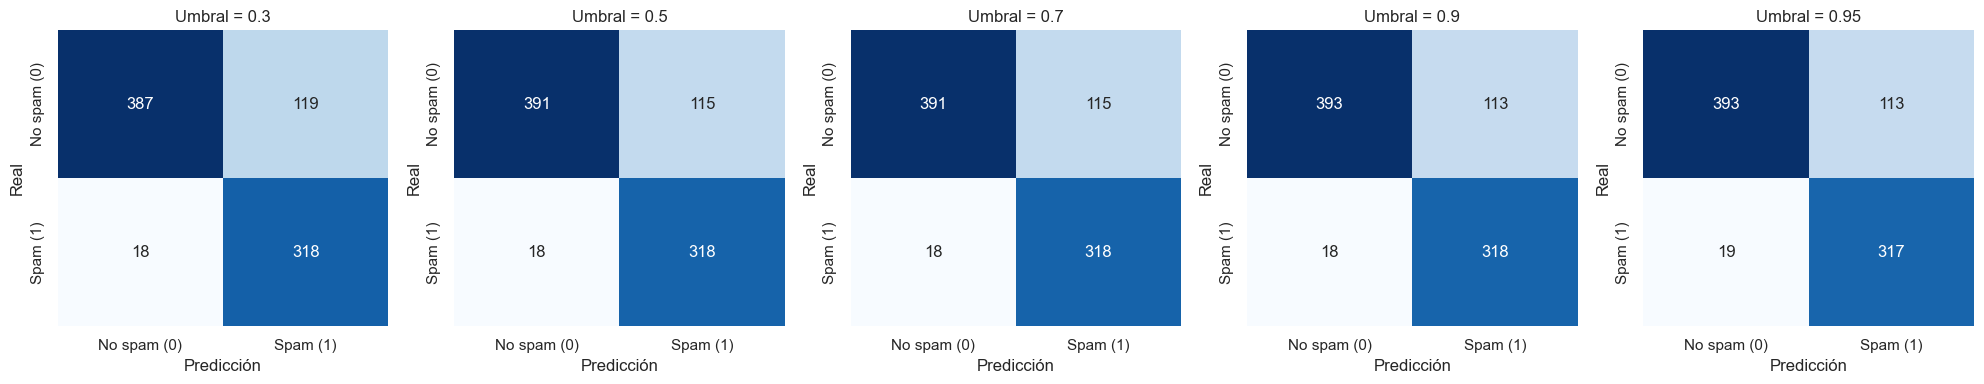

,Umbral,Accuracy,Precision_spam,Recall_spam,F1_spam,MCC
0,0.30,0.84,0.73,0.95,0.82,0.70
1,0.50,0.84,0.73,0.95,0.83,0.70
2,0.70,0.84,0.73,0.95,0.83,0.70
3,0.90,0.84,0.74,0.95,0.83,0.71
4,0.95,0.84,0.74,0.94,0.83,0.71


In [20]:
n = len(cms)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

if n == 1:
    axes = [axes]  # por seguridad si hubiera un solo umbral

labels = ['No spam (0)', 'Spam (1)']

for ax, (thr, cm) in zip(axes, cms):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=labels,
        yticklabels=labels,
        ax=ax
    )
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_title(f'Umbral = {thr}')

plt.tight_layout()
plt.show()

tabla_umbral_red = tabla_umbral.copy()
cols_red = ['Accuracy', 'Precision_spam', 'Recall_spam', 'F1_spam', 'MCC']

tabla_umbral_red[cols_red] = tabla_umbral_red[cols_red].round(2)
tabla_umbral_red


In [21]:
# Elegir el umbral que maximiza F1 para spam
mejor_f1 = tabla_umbral.loc[tabla_umbral['F1_spam'].idxmax(), ['Umbral', 'F1_spam']]
mejor_f1

Umbral     0.900000
F1_spam    0.829205
Name: 3, dtype: float64

In [22]:
mejor_umbral = mejor_f1['Umbral']
mejor_umbral

np.float64(0.9)

## Predicciones con el mejor umbral

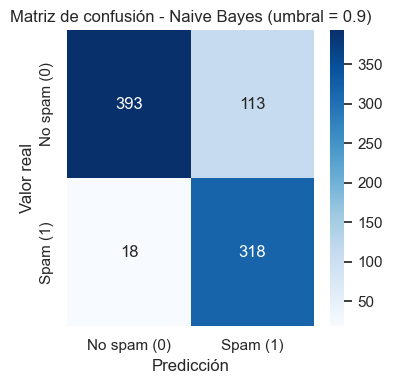


Naive Bayes - Reporte de clasificación (umbral = 0.9)
              precision    recall  f1-score   support

           0       0.96      0.78      0.86       506
           1       0.74      0.95      0.83       336

    accuracy                           0.84       842
   macro avg       0.85      0.86      0.84       842
weighted avg       0.87      0.84      0.85       842



In [23]:
# Predicción binaria usando el mejor umbral
y_pred_best = (proba_spam >= mejor_umbral).astype(int)

# Matriz de confusión y reporte para ese umbral
cm_best = confusion_matrix(y_test, y_pred_best)
labels = ['No spam (0)', 'Spam (1)']

plt.figure(figsize=(4,4))
sns.heatmap(
    cm_best, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels
)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title(f'Matriz de confusión - Naive Bayes (umbral = {mejor_umbral})')
plt.tight_layout()
plt.show()

print(f"\nNaive Bayes - Reporte de clasificación (umbral = {mejor_umbral})")
print(classification_report(y_test, y_pred_best, digits=2))


La mejoría es apenas perceptible, pero podemos notar que aumenta el número TN y disminuye el de FP; esto hace que el accuracy se mantenga en 84% y la precisión aumenta a 0.74, indicando que el modelo reduce la cantidad de correos legítimos clasificados incorrectamente como spam y, por lo tanto, mejora un poco la confianza en que los correos etiquetados como spam realmente lo sean

## Visualizaciones

Forma X_train_2d: (3368, 2)
Forma X_test_2d:  (842, 2)


C:\Users\Luis Oliveros\AppData\Local\Temp\ipykernel_23456\3506561061.py:49: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  test_sc = plt.scatter(


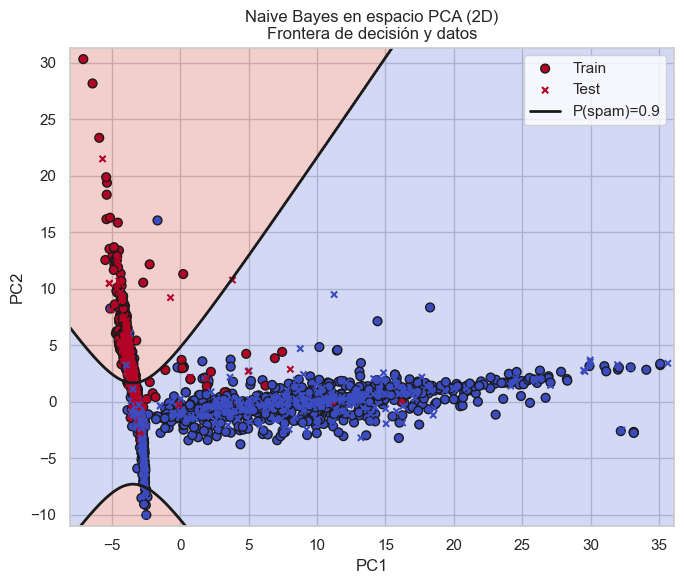

In [30]:
# PCA 
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d  = pca.transform(X_test_scaled)

print("Forma X_train_2d:", X_train_2d.shape)
print("Forma X_test_2d: ", X_test_2d.shape)

# Entrenamos Naive Bayes en el espacio 2D
nb_2d = GaussianNB()
nb_2d.fit(X_train_2d, y_train)

# Mallado
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

# Calcular probabilidad y clase predicha en cada punto de la malla
Z_proba = nb_2d.predict_proba(grid_points)[:, 1].reshape(xx.shape)
Z = (Z_proba >= mejor_umbral).astype(int)

# Convertir y_train / y_test a arrays 1D para colorear
y_train_num = np.ravel(y_train).astype(int)
y_test_num  = np.ravel(y_test).astype(int)

# 6. Figura
plt.figure(figsize=(7, 6))

# Fondo coloreado según la clase predicha
plt.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.coolwarm)

# Línea donde P(spam) = 0.9
plt.contour(xx, yy, Z_proba, levels=[mejor_umbral], colors='k', linewidths=2)

# Puntos de entrenamiento
train_sc = plt.scatter(
    X_train_2d[:, 0], X_train_2d[:, 1],
    c=y_train_num, cmap=plt.cm.coolwarm,
    edgecolor='k', s=40, label='Train'
)

# Puntos de prueba
test_sc = plt.scatter(
    X_test_2d[:, 0], X_test_2d[:, 1],
    c=y_test_num, cmap=plt.cm.coolwarm,
    edgecolor='k', s=20, marker='x', label='Test'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Naive Bayes en espacio PCA (2D)\nFrontera de decisión y datos')

# Proxy para la línea de P(spam)=0.9 en la leyenda
line_proxy = Line2D([0], [0], color='k', linewidth=2, label=f'P(spam)={mejor_umbral}')

plt.legend(handles=[train_sc, test_sc, line_proxy], loc='best')
plt.tight_layout()
plt.show()


* Fondo: es la frontera de decisión de Naive Bayes en ese plano PCA.
    - Zona azul claro: región donde NB predice no spam (0).
    - Zona salmón: región donde NB predice spam (1).

* Puntos:
    - Puntos azules y rojos (“Train”): observaciones del conjunto de entrenamiento en este espacio PCA.
    - Cruces rojas y azules (“Test”): observaciones del conjunto de prueba.

* La nube principal está muy concentrada cerca de PC1 (entre [−5, 5]) y PC2 (entre [−5, 5]).
* Los puntos que se van hacia la derecha (PC1 > 10) son casos muy especiales en términos de combinación de variables y se pueden considerar outliers en el espacio PCA, casi todos no spam.

* El modelo traza una frontera más o menos en forma de cuña:
    - hacia la izquierda y hacia arriba tiende a clasificar como spam en su mayoría,
    - hacia la derecha y abajo, como no spam.

* Se aprecia bastante solapamiento visual entre train y test, lo cual es buena señal: la distribución de test no parece algo radicalmente distinto al entrenamiento en este espacio.

In [31]:
# Datos en PCA 2D
X_train_2d, X_test_2d

# Modelo entrenado en 2D
nb_2d = GaussianNB().fit(X_train_2d, y_train)

# Probabilidades en test (modelo 2D, para esta figura)
proba_test_2d = nb_2d.predict_proba(X_test_2d)[:, 1]

y_test_1d = np.ravel(y_test).astype(int)


In [32]:
# Malla y regiones con el mejor umbral (como antes)
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z_proba = nb_2d.predict_proba(grid_points)[:, 1].reshape(xx.shape)
Z_region = (Z_proba >= mejor_umbral).astype(int)


### Dos gráficos separados: solo no spam y solo spam

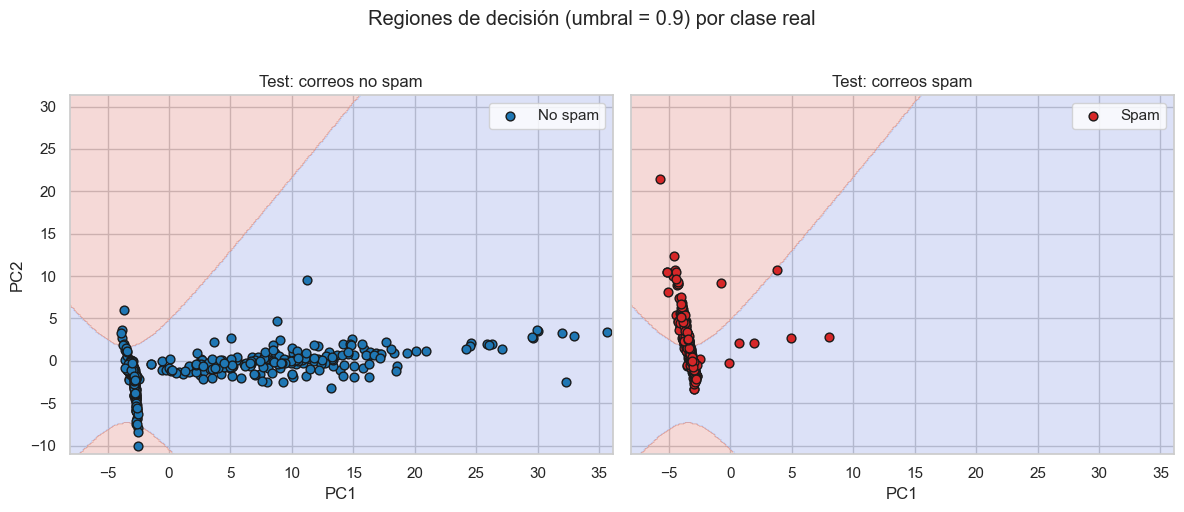

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Máscara por clase real en test
mask_not_spam = (y_test_1d == 0)
mask_spam     = (y_test_1d == 1)

# Panel izquierda: solo no spam
axes[0].contourf(xx, yy, Z_region, alpha=0.2, cmap=plt.cm.coolwarm)
axes[0].scatter(
    X_test_2d[mask_not_spam, 0],
    X_test_2d[mask_not_spam, 1],
    c='tab:blue', edgecolor='k', s=40, label='No spam'
)
axes[0].set_title('Test: correos no spam')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Panel derecha: solo spam
axes[1].contourf(xx, yy, Z_region, alpha=0.2, cmap=plt.cm.coolwarm)
axes[1].scatter(
    X_test_2d[mask_spam, 0],
    X_test_2d[mask_spam, 1],
    c='tab:red', edgecolor='k', s=40, label='Spam'
)
axes[1].set_title('Test: correos spam')
axes[1].set_xlabel('PC1')

for ax in axes:
    ax.legend()

plt.suptitle(f'Regiones de decisión (umbral = {mejor_umbral}) por clase real', y=1.02)
plt.tight_layout()
plt.show()


### Biplot

Varianza explicada PC1 y PC2: [0.56280511 0.12243528]


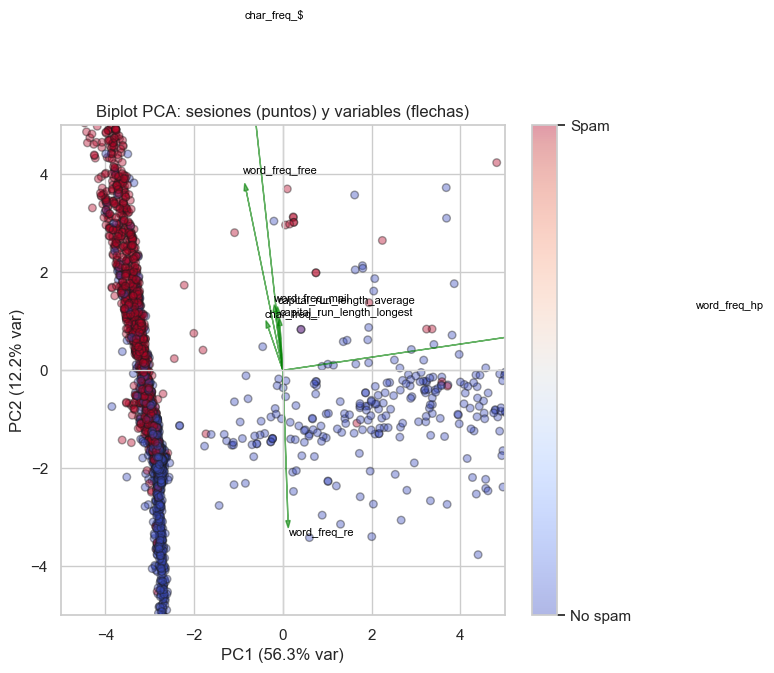

In [34]:
features = X_train.columns

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

print("Varianza explicada PC1 y PC2:", pca.explained_variance_ratio_)

loadings = pca.components_.T    # shape: (n_vars, 2)

# Norma de cada vector de cargas para ordenar importancia
loading_norm = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)

# Elegimos, por ejemplo, las 8 variables más influyentes
k = 8
idx_top = np.argsort(loading_norm)[-k:]

plt.figure(figsize=(8, 7))

# Puntos (correos) en el plano PC1–PC2, coloreados por clase real
y_train_num = np.ravel(y_train).astype(int)
scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train_num,
    cmap=plt.cm.coolwarm,
    alpha=0.4,
    edgecolor='k',
    s=30
)

# Vectores de las variables más relevantes
scale = 9  # factor para alargar flechas y hacerlas visibles

for i in idx_top:
    x_vec = loadings[i, 0] * scale
    y_vec = loadings[i, 1] * scale
    plt.arrow(0, 0, x_vec, y_vec,
              color='green', alpha=0.6,
              head_width=0.1, length_includes_head=True)
    plt.text(x_vec * 1.05, y_vec * 1.05,
             features[i],
             fontsize=8, color='black')

plt.axhline(0, color='lightgray', linewidth=1)
plt.axvline(0, color='lightgray', linewidth=1)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title('Biplot PCA: sesiones (puntos) y variables (flechas)')

cbar = plt.colorbar(scatter, ticks=[0, 1])
cbar.ax.set_yticklabels(['No spam', 'Spam'])

plt.xlim(-5, 5)
plt.ylim(-5, 5)

plt.tight_layout()
plt.show()

Para las 8 variables escogidas para representar en el biplot podemos notar que:
* word_freq_free apunta hacia el cuadrante superior, en una zona donde se observa presencia relevante de puntos rojos. Es un mensaje directo: cuando la frecuencia de “free” crece, el correo se desplaza hacia una región más asociada a spam.

* word_freq_re baja hacia el cuadrante inferior: está capturando un uso más bien “legítimo” de respuestas y reenvíos (Re:). Esa dirección cae sobre una zona con mezcla, pero con bastante azul, lo que puede cuadrar con correos de conversación cotidiana o corporativa.

* Las variables de capitales (capital_run_length_average, capital_run_length_longest, capital_run_length_total) se proyectan hacia la derecha junto con algunas palabras técnicas. Indican que correos con bloques largos de mayúsculas y secuencias capitalizadas se desplazan hacia esa región. El modelo ve ahí una combinación de énfasis (títulos, gritos de marketing) que en muchos casos se vincula a spam.

* word_freq_hp aparece muy separada hacia la derecha, casi aislada. Eso sugiere que esta palabra define un patrón bastante específico de correos (por ejemplo, tráfico relacionado a Hewlett-Packard en el dataset original) y explica una parte de la variabilidad independiente de otras palabras.

En resumen, el biplot muestra que las palabras y patrones elegidos empujan los correos hacia zonas del plano coherentes con su comportamiento de spam o no spam. La frecuencia de “free” y las variables de capitales desplazan los puntos hacia regiones donde se concentran muchos correos spam, lo que refuerza su rol como indicadores de mensajes promocionales agresivos. En cambio, “re” se asocia más a correos de intercambio habitual, mientras que “hp” genera un grupo muy específico de mensajes con dinámica propia.

# Ejercicios

1. Entrenar y evaluar GaussianNB en los siguientes escenarios y calcular matriz de confusión, accuracy, F1 de spam y AUC. Realizar una breve conclusión sobre qué cambió y por qué.
    1. Sin logaritmo y con StandardScaler.
    2. Con log1p + StandardScaler.

2. Usar GridSearchCV solo sobre var_smoothing (por ejemplo [1e-9, 1e-8, 1e-7, 1e-6]) con validación cruzada estratificada y reportar:
    1. El mejor valor encontrado
    2. Las métricas correspondientes al valor asociado
    3. Interpretación de los resultados (¿la ganancia justifica la complejidad extra?)
